# Drug200 : Analyzing Prescription Patterns Based on Patient Characteristic

**Goal:** Understand the relationship between patient characteristic (age, sex, pressure, cholesterol, and sodium to pottasium ratio ) and the drug the were prescribe

**Data Source:** 'drug200.csv' - the public "Drug Classification" dataset (200 patient records), available on Kaggle.

**Notebook Structure:**
1. Import and Inspect the data
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Relationship analysis between variables
5. Interactive visualizations with Plotly
6. Concluction and insights

# 1. Import and Inspect the data

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option ('display.max_columns', None)

In [2]:
df = pd.read_csv('drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [3]:
df.shape

(200, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 12.5 KB


In [5]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


**Initial Obsrvation:** the dataset contain 200 rows and 6 columns ('Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'). Based on 'df.info()', every column is fully populated (200 non-null), so there are no missing value to handle

# 2. Data Cleaning

In [6]:
#check for duplicatedrows
print(f'Number of duplicate rows: , {df.duplicated().sum()}')

Number of duplicate rows: , 0


In [7]:
#check missing values per column 
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [8]:
#check spelling capitalization concistency in categorical column
for col in ['Sex', 'BP', 'Cholesterol', 'Drug']:
    print(col, '->', df[col].unique())
    

Sex -> <ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
BP -> <ArrowStringArray>
['HIGH', 'LOW', 'NORMAL']
Length: 3, dtype: str
Cholesterol -> <ArrowStringArray>
['HIGH', 'NORMAL']
Length: 2, dtype: str
Drug -> <ArrowStringArray>
['DrugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str


**Note:** the 'Drug' column in the original dataset often has inconcistenct capitalization (e.g. 'DrugY' vs 'drugC'). If that shows up in the output above, standardize it first so aggregation counts don't get spill across near-duplicate labels:

In [9]:
df['Drug'] = df['Drug'].str.capitalize()
df['Drug'].unique()

<ArrowStringArray>
['Drugy', 'Drugc', 'Drugx', 'Druga', 'Drugb']
Length: 5, dtype: str

In [10]:
# Make sure categorical columns have the right dtype
cat_col = ['Sex', 'BP', 'Cholesterol', 'Drug']
df[cat_col] = df[cat_col].astype('category')
df.dtypes

Age               int64
Sex            category
BP             category
Cholesterol    category
Na_to_K         float64
Drug           category
dtype: object

# 3.Exploratory Data Analysis (EDA)

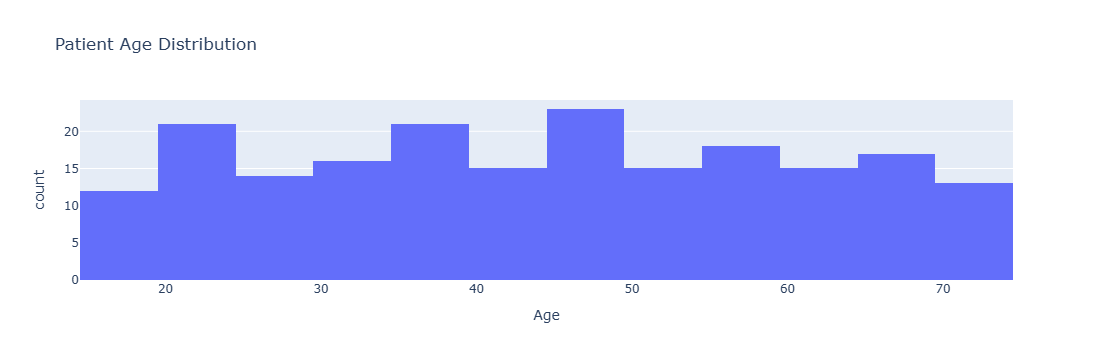

In [29]:
# Age distribution
fig = px.histogram(df, x='Age', nbins=20, title='Patient Age Distribution')
fig.show()

In [12]:
# Na_to_K distribution
df_drug_count = df['Drug'].value_counts().reset_index()
df_drug_count.columns = ['Drug', 'Patient_Counts']
df_drug_count

,Drug,Patient_Counts
0,Drugy,91
1,Drugx,54
2,Druga,23
3,Drugb,16
4,Drugc,16


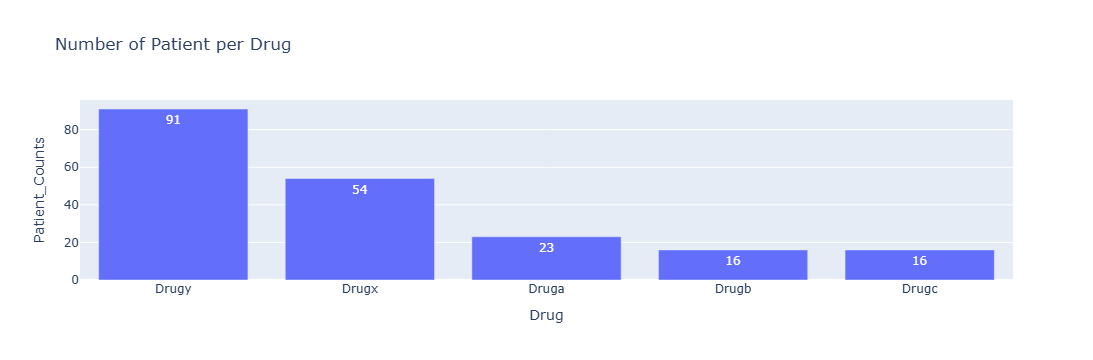

In [13]:
fig = px.bar(df_drug_count, x='Drug', y='Patient_Counts', title='Number of Patient per Drug', text='Patient_Counts' )
fig.show()

In [14]:
# Distribution of Sex, BP and Cholesterol 
for col in ['Sex', 'BP', 'Cholesterol']:
    print(df[col].value_counts(), '\n')

Sex
M    104
F     96
Name: count, dtype: int64 

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64 

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64 



# 4. Relationship Analysis Between Variables

**Analysis Questions:**
- Does the Na_to_K ratio influance which drug is prescribed?
- Is age related to a particular drug?
- Are blood pressure (BP) or cholesterol level related to drug choice?

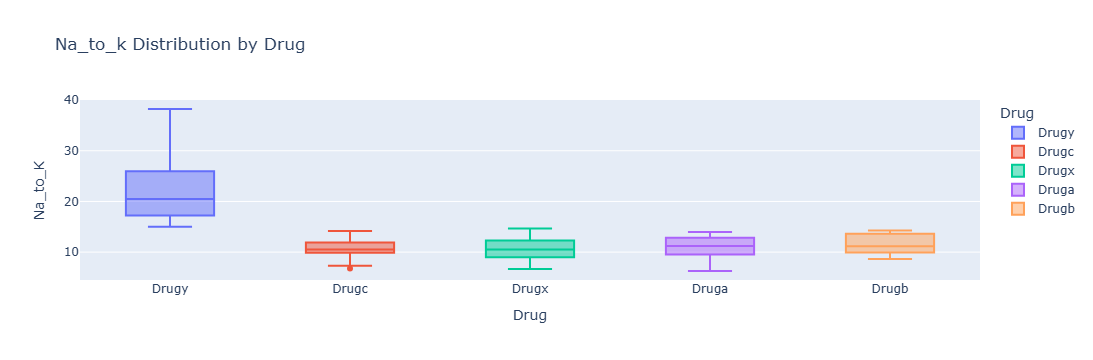

In [15]:
fig = px.box(df, x='Drug', y='Na_to_K', color='Drug', 
             title='Na_to_k Distribution by Drug' )
fig.show()

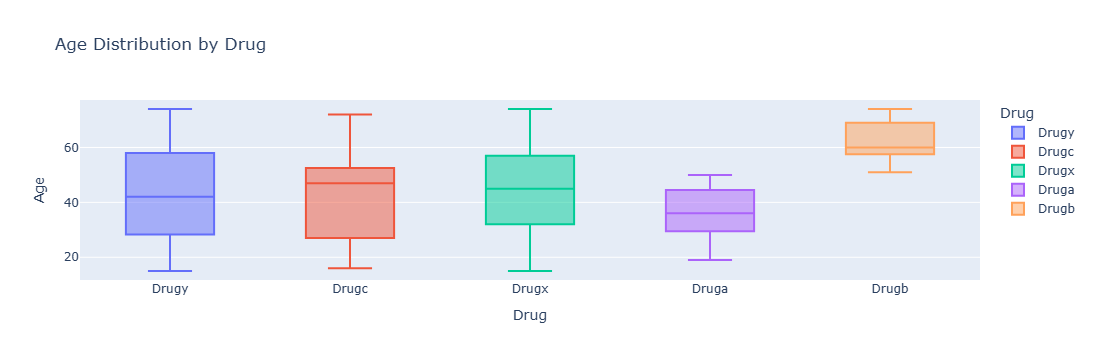

In [16]:
fig = px.box(df, x='Drug', y='Age', color='Drug', title='Age Distribution by Drug' )
fig.show()

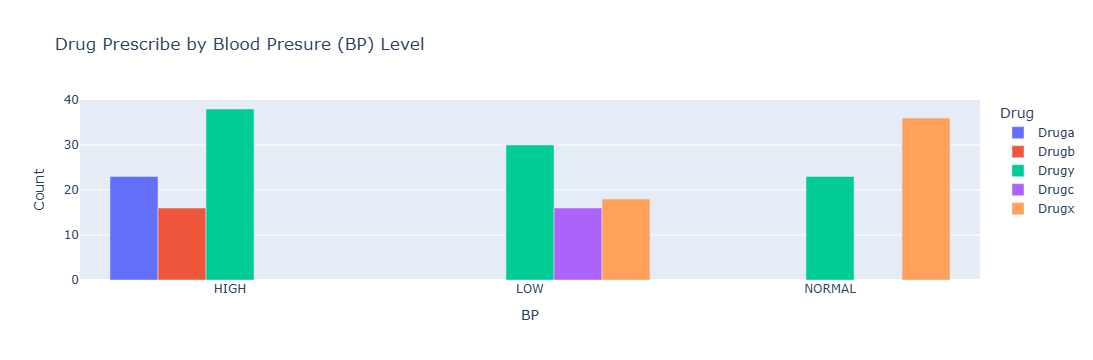

In [17]:
# Relationship between BP and Drug
bp_drug = df.groupby(['BP', 'Drug']).size().reset_index(name='Count')
fig =px.bar(bp_drug, x="BP", y='Count', color='Drug', barmode='group', title='Drug Prescribe by Blood Presure (BP) Level')
fig.show()

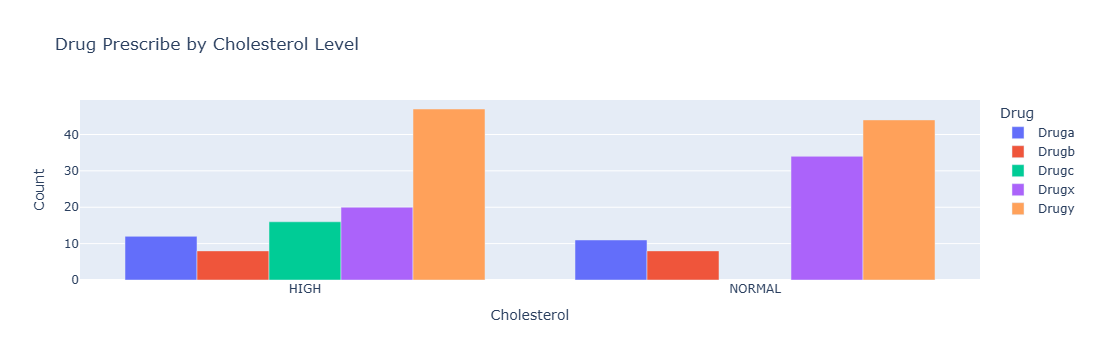

In [20]:
# Relationship between Cholesterol and Drug
chol_drug = df.groupby(['Cholesterol', 'Drug']).size().reset_index(name='Count')
fig = px.bar(chol_drug, x='Cholesterol', y="Count", color='Drug', barmode='group', title='Drug Prescribe by Cholesterol Level')
fig.show()

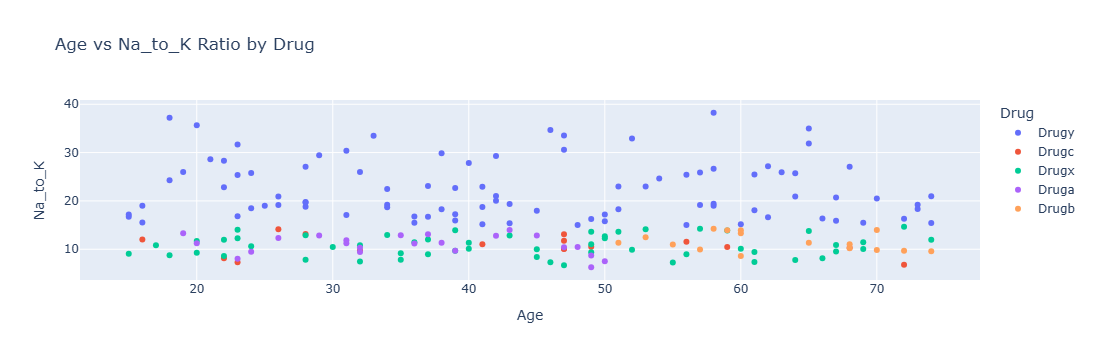

In [22]:
# Scatter plot: Age vs Na_to_k colored by Drug
fig = px.scatter(df, x='Age', y='Na_to_K', color='Drug', title='Age vs Na_to_K Ratio by Drug')
fig.show()

# 5. Interactive Visualization

All the chart above are already interactive with 'plotly.express' (hover, zoom and filter directly via the legend ) - this demonstrated the ability to produce more engaging visualization than a static chart.

# 6. Conclusion & Insight

*Analysis of the drug200 dataset reveals several clear prescribing patterns based on patient characteristics:*

- Patients with a Na_to_K ratio above approximately 15 tend to be prescibed Drugy, regardless of their age.
- Age shows clear cutoff between two drugs: Druga is exclusively prescribed to patients aged 50 and under (median 36), while Drugb is exclusively
  prescribed to patients aged 51 and older (median 60) - the two age ranges never overlap. Drugc, Drugx, Drugy, by contrast, are prescribed
  across a much wider and overlapping age range.
- Blood pressure (BP) does appear to be clearly related to drug choice - Druga and Drugb are prescribed exclusively to patients with high BP,
  Drugc exclusively to low BP, Drug X never appears in High-BP patients. Only Drugy is prescribed across all BP levels.
- High cholesterol is most associated with Drugc - this is the only drug never prescribed to patients with normal choesterol, suggesting
  it may be specifically indicated for high-cholesterol cases. In contrast, Drugy is consistently the most prescribed drug across both cholesterol
  levels, indicated isn't tied to a specific cholesterol condition - similar to the pattern seen with blood pressure.


**Limitations:** this dataset is small (200 rows) and synthetic/educational, so the patterns found here shouln't be generalized to a real patient population without further validation.

**Data source:** 'drug200.csv' - the "Drug Classification" dataset by Pratham Tripathi, via Kaggle.

**Tools used:** 'Python', 'Jupyter Notebook', 'pandas' - data loading and manipulation, 'numpy' - numerical operations, 'plotly.express' - interactive data visualization.